# Cálculos para el sistema de intercambiador de calor doble en un recipiente aislado

![Blank diagram.png](<attachment:Blank diagram.png>)
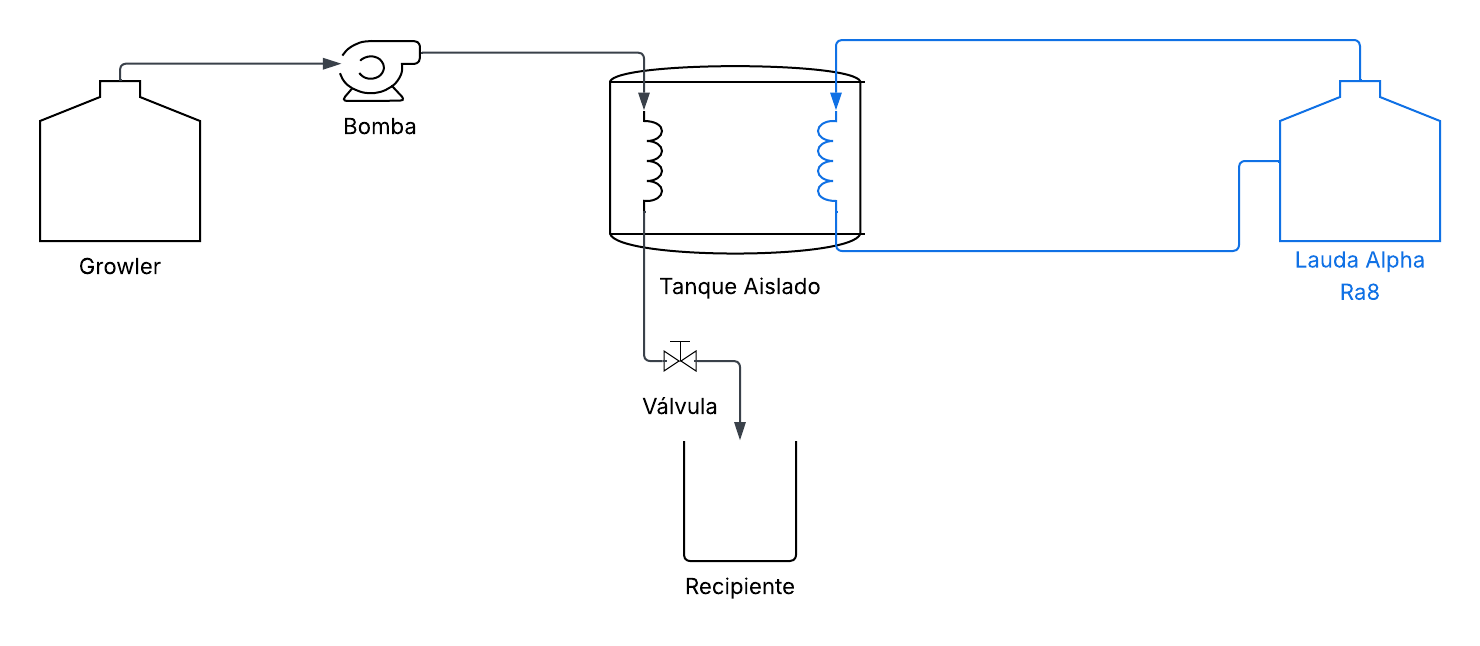

## Ecuaciones gobernantes

### Cálculo de la temperatura del recipiente en función del tiempo

La ecuación de balance de energía es:
$$\rho C_p V \frac{dT}{dt} = - h_{etanol} A_{etanol} (T(t) - T_{etanol})$$

Donde:
- $\rho$: Densidad del agua en el recipiente
- $V$: Volumen de agua en el recipiente
- $T(t)$: Temperatura del agua en el recipiente en función del tiempo
- $h_{etanol}$: Coeficiente de convección natural de un tubo horizontal a la temperatura del etanol


Reordenando y agrupando términos:
$$\frac{dT}{dt} + T(t) \left[ \frac{h_{etanol} A_{etanol}}{\rho V C_p} \right] = \frac{h_{etanol} A_{etanol} T_{etanol}}{\rho V C_p}$$

Definiendo las constantes **A** y **B**:
* $A = \frac{h_{etanol} A_{etanol}}{\rho V C_p}$
* $B = \frac{h_{etanol} A_{etanol} T_{etanol}}{\rho V C_p}$

La ecuación queda de la forma:
$$\frac{dT}{dt} + A \cdot T(t) = B$$

Aplicando el **factor integrante** $e^{At}$ e integrando con la condición inicial $T(0) = T_0$, llegamos a la solución general:

$$T(t) = \frac{B}{A} + \left( T_0 - \frac{B}{A} \right) e^{-At}$$

### Cálculo de las temperaturas de salida del intercambiador de calor en función del tiempo

Usamos la eficiencia de un intercambiador de calor 

$$
\varepsilon = 1 - e^{-NTU}
$$

Donde $NTU = \frac{UA}{C_{min}}$. Así, las temperaturas de salida del agua y del etanol están dadas por:

$$
T_{out,etanol} = T_{in,etanol} + \varepsilon (T(t) - T_{in,etanol})
$$

$$
T_{out,agua} = T_{in,agua} - \varepsilon (T_{in,agua} - T(t))
$$

Recordemos también que el valor de $UA$ se calcula según:

$$
\frac{1}{UA} = \frac{1}{h_{int}A_{int}} + \frac{\ln(D_o/D_i)}{2\pi L k_{tubo}} + \frac{1}{h_{out}A_{out}}
$$

## Código Implementado

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP
from tabulate import tabulate

In [ ]:
class Enfriador:

    def __init__(self, T_in_agua, T_in_etanol, Q_agua, Q_etanol, 
                 D_agua, D_etanol, k_tuberia_agua, k_tuberia_etanol, e_agua, e_etanol,
                 L_agua, L_etanol, V_recipiente_array):
        
        self.T_in_agua = T_in_agua # Temperatura de entrada del agua (K)
        self.T_in_etanol = T_in_etanol # Temperatura de entrada del etanol (K)
        self.Q_agua = Q_agua # Caudal de agua (m³/s)
        self.Q_etanol = Q_etanol # Caudal del etanol (m³/s)
        self.P = 101325 # Presión atmosférica (Pa)
        self.T0_recipiente = T_in_agua # Temperatura de referencia para el recipiente (K)
        self.D_agua = D_agua # Diámetro interno de la tubería para el agua (m)
        self.D_etanol = D_etanol # Diámetro interno de la tubería para el etanol (m)
        self.k_tuberia_agua = k_tuberia_agua # Conductividad térmica de la tubería para el agua (W/m·K)
        self.k_tuberia_etanol = k_tuberia_etanol # Conductividad térmica de la tubería para el etanol (W/m·K)
        self.e_agua = e_agua # Espesor de la tubería para el agua (m)
        self.e_etanol = e_etanol # Espesor de la tubería para el etanol (m)
        self.L_agua = L_agua # Longitud de la tubería para el agua (m)
        self.L_etanol = L_etanol # Longitud de la tubería para el etanol (m)
        self.V_recipiente_array = V_recipiente_array # Volumen del recipiente (m³)
        self.V_total = 10e-3 # Volumen total de fluido en el sistema (m³)

        self.ejecutar()

    def calcular_propiedades(self):
        '''Defina las propiedades de los fluidos utilizando CoolProp.'''
        # Propiedades del agua
        Tm_agua = self.T_in_agua # Temperatura media del agua (K)
        self.rho_agua = CP.PropsSI('D', 'T', Tm_agua, 'P', self.P, 'Water') # Densidad del agua (kg/m³)
        self.Cp_agua = CP.PropsSI('C', 'T', Tm_agua, 'P', self.P, 'Water') # Capacidad calorífica del agua (J/kg·K)
        self.mu_agua = CP.PropsSI('V', 'T', Tm_agua, 'P', self.P, 'Water') # Viscosidad del agua (Pa·s)
        self.k_agua = CP.PropsSI('L', 'T', Tm_agua, 'P', self.P, 'Water') # Conductividad térmica del agua (W/m·K)
        self.beta_agua = CP.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', Tm_agua, 'P', self.P, 'Water') # Coeficiente de expansión volumétrica del agua (1/K)
        self.nu_agua = self.mu_agua / self.rho_agua # Viscosidad cinemática del agua (m²/s)
        self.m_agua = self.rho_agua * self.Q_agua # Masa de agua que fluye por segundo (kg/s)

        # Propiedades del etanol (como no conozclo la temperatura de salida, se evalúa en la de entrada)
        self.rho_etanol = CP.PropsSI('D', 'T', self.T_in_etanol, 'P', self.P, 'Ethanol') # Densidad del etanol (kg/m³)
        self.Cp_etanol = CP.PropsSI('C', 'T', self.T_in_etanol, 'P', self.P, 'Ethanol') # Capacidad calorífica del etanol (J/kg·K)
        self.mu_etanol = CP.PropsSI('V', 'T', self.T_in_etanol, 'P', self.P, 'Ethanol') # Viscosidad del etanol (Pa·s)
        self.k_etanol = CP.PropsSI('L', 'T', self.T_in_etanol, 'P', self.P, 'Ethanol') # Conductividad térmica del etanol (W/m·K)
        self.beta_etanol = CP.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', self.T_in_etanol, 'P', self.P, 'Ethanol') # Coeficiente de expansión volumétrica del etanol (1/K)
        self.nu_etanol = self.mu_etanol / self.rho_etanol # Viscosidad cinemática del etanol (m²/s)
        self.m_etanol = self.rho_etanol * self.Q_etanol # Masa de etanol que fluye por segundo (kg/s)

    def conveccion_interna(self):
        '''Calcule los coeficientes de transferencia de calor por convección interna para ambos fluidos.'''
        # Velocidades de los fluidos
        self.v_agua = self.Q_agua / (np.pi * (self.D_agua / 2) ** 2) # Velocidad del agua (m/s)
        self.v_etanol = self.Q_etanol / (np.pi * (self.D_etanol / 2) ** 2) # Velocidad del etanol (m/s)

        # Números de Reynolds
        self.Re_agua = (self.rho_agua * self.v_agua * self.D_agua) / self.mu_agua # Número de Reynolds para el agua
        self.Re_etanol = (self.rho_etanol * self.v_etanol * self.D_etanol) / self.mu_etanol # Número de Reynolds para el etanol

        # Números de Prandtl
        self.Pr_agua = (self.Cp_agua * self.mu_agua) / self.k_agua # Número de Prandtl para el agua
        self.Pr_etanol = (self.Cp_etanol * self.mu_etanol) / self.k_etanol # Número de Prandtl para el etanol

        if self.Re_agua < 2300:
            self.Nu_agua_interna = 4.36
        else:
            self.Nu_agua_interna = 0.023 * (self.Re_agua ** 0.8) * (self.Pr_agua ** 0.3)

        if self.Re_etanol < 2300:
            self.Nu_etanol_interna = 4.36
        else:
            self.Nu_etanol_interna = 0.023 * (self.Re_etanol ** 0.8) * (self.Pr_etanol ** 0.4)   


        self.h_agua_interna = (self.Nu_agua_interna * self.k_agua) / self.D_agua # Coeficiente de transferencia de calor por convección interna para el agua (W/m²·K)
        self.h_etanol_interna = (self.Nu_etanol_interna * self.k_etanol) / self.D_etanol # Coeficiente de transferencia de calor por convección interna para el etanol (W/m²·K)

        # Recordemos que n = 0.4 para calentamiento y n = 0.3 para enfriamiento, por lo que se ha considerado el caso de enfriamiento para el etanol.

        self.R_conveccion_interna_agua = 1 / (self.h_agua_interna * np.pi * self.D_agua * self.L_agua) # Resistencia térmica por convección interna para el agua (K/W)
        self.R_conveccion_interna_etanol = 1 / (self.h_etanol_interna * np.pi * self.D_etanol * self.L_etanol) # Resistencia térmica por convección interna para el etanol (K/W)

    def Grashof(self, beta, T_inf, T_s, L, nu):
        return (9.81 * beta * (T_inf - T_s) * (L**3)) / (nu**2)

    def conveccion_externa(self):
        '''Calcule los coeficientes de transferencia de calor por convección natural para ambos fluidos.'''
        self.Gr_agua = self.Grashof(self.beta_agua, self.T0_recipiente, self.T_in_agua, self.D_agua, self.nu_agua)
        self.Gr_etanol = self.Grashof(self.beta_etanol, self.T0_recipiente, self.T_in_etanol, self.D_etanol, self.nu_etanol)

        self.Ra_agua = self.Gr_agua * self.Pr_agua
        self.Ra_etanol = self.Gr_etanol * self.Pr_etanol


        if self.Ra_agua < 1e12:
            denominador = 1 + ((0.559 / self.Pr_agua) ** (9/16))
            numerador = 0.387 * (self.Ra_agua ** (1/6))
            self.nusselt_agua_natural = (
                1 + (numerador / (denominador ** (8/27)))
                    ) ** 2

        if self.Ra_etanol < 1e12:
            denominador = 1 + ((0.559 / self.Pr_etanol) ** (9/16))
            numerador = 0.387 * (self.Ra_etanol ** (1/6))
            self.nusselt_etanol_natural = (
                1 + (numerador / (denominador ** (8/27)))
                    ) ** 2
            
        self.h_agua_natural = (self.nusselt_agua_natural * self.k_agua) / self.D_agua # Coeficiente de transferencia de calor por convección natural para el agua (W/m²·K)
        self.h_etanol_natural = (self.nusselt_etanol_natural * self.k_etanol) / self.D_etanol # Coeficiente de transferencia de calor por convección natural para el etanol (W/m²·K)

        self.R_conveccion_natural_agua = 1 / (self.h_agua_natural * np.pi * self.Do_agua * self.L_agua) # Resistencia térmica por convección natural para el agua (K/W)
        self.R_conveccion_natural_etanol = 1 / (self.h_etanol_natural * np.pi * self.Do_etanol * self.L_etanol) # Resistencia térmica por convección natural para el etanol (K/W)

    def conduccion_tubos(self):
        '''Calcule la resistencia térmica por conducción a través de las paredes de las tuberías para ambos fluidos.'''
        self.Do_agua = self.D_agua + 2 * self.e_agua # Diámetro externo de la tubería para el agua (m)
        self.Do_etanol = self.D_etanol + 2 * self.e_etanol # Diámetro externo de la tubería para el etanol (m)
        self.R_conduccion_agua = np.log(self.Do_agua / self.D_agua) / (2 * np.pi * self.k_tuberia_agua * self.L_agua) # Resistencia térmica por conducción para el agua (K/W)
        self.R_conduccion_etanol = np.log(self.Do_etanol / self.D_etanol) / (2 * np.pi * self.k_tuberia_etanol * self.L_etanol) # Resistencia térmica por conducción para el etanol (K/W)   

    def calcular_UA(self):
        '''Calcule el valor de UA para ambos fluidos.'''
        self.UA_agua = 1 / (self.R_conveccion_interna_agua + self.R_conduccion_agua + self.R_conveccion_natural_agua) # Valor de UA para el agua (W/K)
        self.UA_etanol = 1 / (self.R_conveccion_interna_etanol + self.R_conduccion_etanol + self.R_conveccion_natural_etanol) # Valor de UA para el etanol (W/K)


    def calcular_T_recipiente(self):
        self.t = np.linspace(0, 3600, 100) # Tiempo en segundos (1 hora)
        A_etanol = np.pi * self.Do_etanol * self.L_etanol # Área de transferencia de calor para el etanol (m²)

        self.T_recipientes_arrays = []
    
        plt.figure(figsize=(10, 6))
        
        for V_recipiente in self.V_recipiente_array:

            A = ((self.h_etanol_natural * A_etanol)) / (self.rho_agua * self.Cp_agua * V_recipiente) 
            B = ((self.h_etanol_natural * A_etanol * self.T_in_etanol)) / (self.rho_agua * self.Cp_agua * V_recipiente)

            T_recipiente = (B / A) + (self.T0_recipiente - (B / A)) * np.exp(-A * self.t) # Temperatura del recipiente en función del tiempo (K)

            self.T_recipientes_arrays.append(T_recipiente)

            # Grafico de la temperatura del recipiente en función del tiempo
            plt.plot(self.t / 60, T_recipiente - 273.15, label=f'Volumen del recipiente: {V_recipiente*1e3:.1f} L')

        plt.axhline(self.T0_recipiente - 273.15, color='r', linestyle='--', label='Temperatura de referencia (°C)')
        plt.xlabel('Tiempo (min)')
        plt.ylabel('Temperatura (°C)')
        plt.title('Evolución de la temperatura del recipiente con el tiempo')
        plt.legend()
        plt.grid()
        plt.show()

    def calcular_T_out(self):
        self.NTU_etanol = self.UA_etanol / (self.m_etanol * self.Cp_etanol) # Número de unidades de transferencia para el etanol
        self.efectividad_etanol = 1 - np.exp(-self.NTU_etanol) # Efectividad del intercambiador para el etanol

        self.NTU_agua = self.UA_agua / (self.m_agua * self.Cp_agua) # Número de unidades de transferencia para el agua
        self.efectividad_agua = 1 - np.exp(-self.NTU_agua) # Efectividad del intercambiador para el agua

        factor_ajuste = 0.539 # Factor de ajuste según el real y el teórico

        # # MODIFICAMOS LA EFECTIVIDAD PARA VER CÓMO CAMBIAN LOS CÁLCULOS
        self.efectividad_etanol *= factor_ajuste
        self.efectividad_agua *= factor_ajuste

        plt.figure(figsize=(10, 6))

        for i in range(len(self.T_recipientes_arrays)):

            T_recipiente = self.T_recipientes_arrays[i]
            volumen_recipiente = self.V_recipiente_array[i]
            self.T_out_etanol = self.T_in_etanol + self.efectividad_etanol * (T_recipiente - self.T_in_etanol) # Temperatura de salida del etanol (K)
            self.T_out_agua = self.T_in_agua - self.efectividad_agua * (self.T_in_agua - T_recipiente) # Temperatura de salida del agua (K)

            # Grafico de la temperatura de salida del etanol y el agua en función del tiempo
            # plt.plot(self.t / 60, self.T_out_etanol - 273.15, label='Temperatura de salida del etanol (°C)')
            plt.plot(self.t / 60, self.T_out_agua - 273.15, label=f'Volumen del recipiente: {volumen_recipiente*1e3:.1f} L')

        plt.axhline(self.T0_recipiente - 273.15, color='r', linestyle='--', label='Temperatura de referencia (°C)')
        plt.xlabel('Tiempo (min)')
        plt.ylabel('Temperatura (°C)')
        plt.title('Evolución de la temperatura de salida del agua con el tiempo')
        plt.legend()
        plt.grid()
        plt.show()

    def mostrar_resultados(self):
        tabla = [
            ['Propiedad', 'Agua', 'Etanol'],
            ['Efectividad', self.efectividad_agua, self.efectividad_etanol],
            ['Número de unidades de transferencia (NTU)', self.NTU_agua, self.NTU_etanol],
            ['Coeficiente de transferencia de calor por convección interna (W/m²·K)', self.h_agua_interna, self.h_etanol_interna],
            ['Coeficiente de transferencia de calor por convección natural (W/m²·K)', self.h_agua_natural, self.h_etanol_natural],
            ['Resistencia térmica por conducción a través de las paredes de las tuberías (K/W)', self.R_conduccion_agua, self.R_conduccion_etanol],
            ['Valor de UA (W/K)', self.UA_agua, self.UA_etanol]
        ]
        
        print(tabulate(tabla, headers='firstrow', tablefmt='grid', floatfmt=".4f"))
            

    def ejecutar(self):
        self.calcular_propiedades()
        self.conveccion_interna()
        self.conduccion_tubos()
        self.conveccion_externa()
        self.calcular_UA()
        self.calcular_T_recipiente()
        self.calcular_T_out()
        self.mostrar_resultados()

## Ejemplo de uso

### Prueba con tubería de silicona y diámetro de 1/4 de tubería de cobre de 1 m

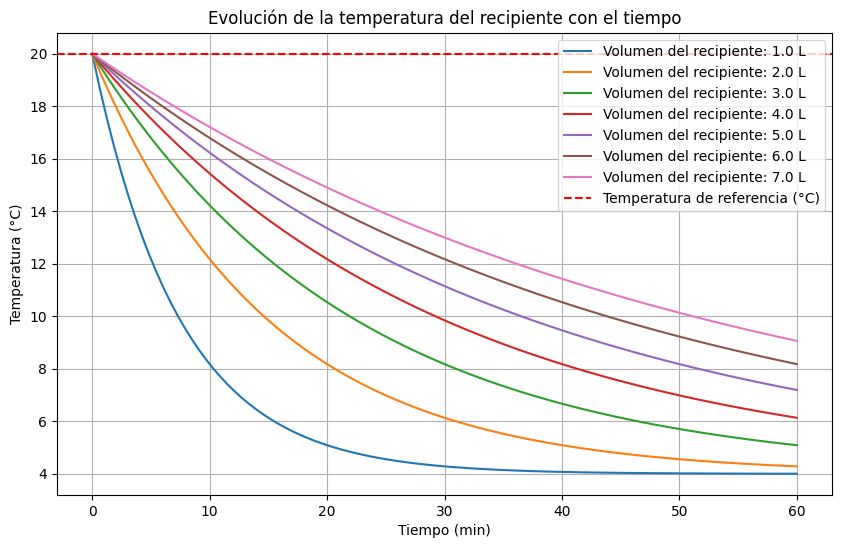

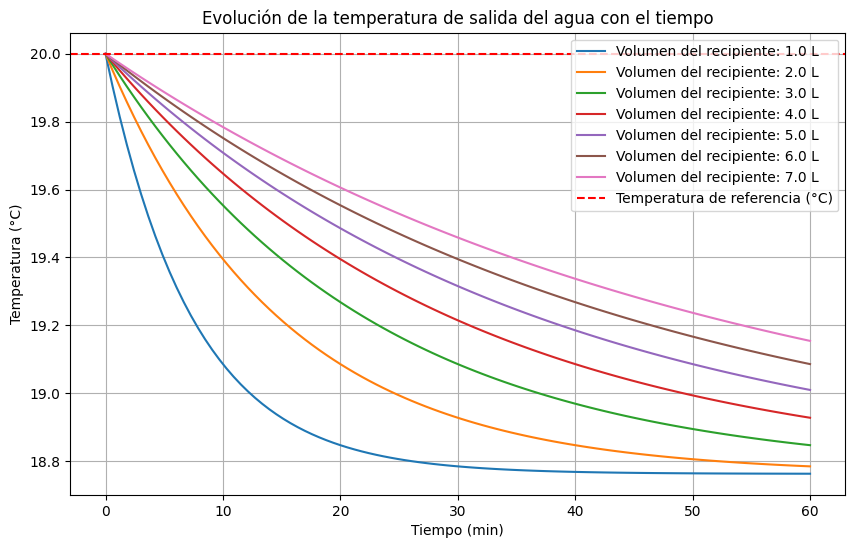

+----------------------------------------------------------------------------------+-----------+-----------+
| Propiedad                                                                        |      Agua |    Etanol |
+==================================================================================+===========+===========+
| Efectividad                                                                      |    0.0773 |    0.0102 |
+----------------------------------------------------------------------------------+-----------+-----------+
| Número de unidades de transferencia (NTU)                                        |    0.1549 |    0.0192 |
+----------------------------------------------------------------------------------+-----------+-----------+
| Coeficiente de transferencia de calor por convección interna (W/m²·K)            | 2829.2355 | 8558.6940 |
+----------------------------------------------------------------------------------+-----------+-----------+
| Coeficiente de tr

In [18]:
T_in_agua = 20 + 273.15 # Temperatura de entrada del agua (K)
T_in_etanol = 4 + 273.15 # Temperatura de entrada del etanol (K)
Q_agua = 1 * 0.001 / 60 # Caudal de agua (1 L/min convertido a m³/s)
Q_etanol = 15 * 0.001 / 60 # Caudal de etanol (15 L/min convertido a m³/s)
D_in_agua = 6e-3 # m, diámetro interior del tubo (6 mm)
D_in_etanol = (6.35 - 0.76) / 1000 # m, diámetro interior del tubo (6.35 mm de diámetro exterior menos 0.76 mm de espesor)  
e_tubo_agua = 1e-3 # m, espesor del tubo (1 mm)
e_tubo_etanol = 0.76 / 1000 # m, espesor del tubo (0.76 mm)
L_tubo_agua = 5 # m, longitud del tubo
L_tubo_etanol = 1 # m, longitud del tubo
k_tubo_agua = 1 # W/m·K, conductividad térmica de la silicona
k_tubo_etanol = 390 # W/m·K, conductividad térmica del cobre (material de las tuberías)
V_recipiente_array = np.linspace(1e-3, 7e-3, 7) # m³, volumen del recipiente (1 L a 7 L)

enfriador = Enfriador(T_in_agua=T_in_agua, T_in_etanol=T_in_etanol, 
                      Q_agua=Q_agua, Q_etanol=Q_etanol, D_agua=D_in_agua, D_etanol=D_in_etanol, 
                      k_tuberia_agua=k_tubo_agua, k_tuberia_etanol=k_tubo_etanol, e_agua=e_tubo_agua, e_etanol=e_tubo_etanol, 
                      L_agua=L_tubo_agua, L_etanol=L_tubo_etanol, V_recipiente_array=V_recipiente_array)